# Train Machine Learning Model on SNOTEL, PRISM, and DEM Data

This notebook will utilize data downloaded and prepared in previous notebooks in training a machine learning model. The model goals are as follows:

__Target variable:__
* SWE (Snow-Water Equivalent) at daily resolution

__Predictor variables:__
* Minimum Temperature
* Maximum Temperature
* Daily Precipitation
* Cumulative Precipitation
* Rolling 3-day mean of Tmin
* Rolling 3-day mean of Tmax
* Elevation
* Slope
* Aspect Northness
* Aspect Eastness

SWE will be predicted using RandomForests or XGBoost Algorithms (talk about why)

## Step 1: Import Libraries and Set Paths

In [27]:
# import libraries

# file management
import os
import pathlib
from pathlib import Path

# datatypes
import numpy as np
import pandas as pd
import xarray as xr

# geospatial data
import geopandas as gpd
import rioxarray as rxr

# machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
#import xgboost as xgb

# plotting
import matplotlib
import matplotlib.pyplot as plt
import holoviews as hv
import hvplot.pandas

In [4]:
# set directories
proj_dir = os.path.join(pathlib.Path.home(),
                        'Documents',
                        'Graduate_School',
                        'EDA_Certificate', 
                        'Summer', 
                        'snow-drought-modeling')

raw_data_dir = os.path.join(proj_dir, 'data', 'raw')
cleaned_data_dir = os.path.join(proj_dir, 'data', 'cleaned')

## Step 2: Import Data

In [40]:
# set paths

ml_dir = Path(cleaned_data_dir, 'machine_learning')
train_path = Path(ml_dir, 'stations_train.parquet')
test_path = Path(ml_dir, 'stations_test.parquet')

In [41]:
# read files

if os.path.exists(train_path):
    # import
    stations_train = pd.read_parquet(train_path)
    # print success
    print("Training data successfully imported!")
else:
    print(f"Training data not found. Check {ml_dir} for file.")

if os.path.exists(test_path):
    stations_test = pd.read_parquet(test_path)
    print("Testing data successfully imported!")
else:
    print(f"Test data not found. Check {ml_dir} for file.")

Training data successfully imported!
Testing data successfully imported!


In [42]:
# check out training to remember shape
stations_train

,date,stationTriplet,latitude,longitude,swe_mm,prism_ppt_mm,prism_tmin_c,prism_tmax_c,elevation,slope,aspect_north,aspect_east,prism_tmin_c_roll_3d,prism_tmax_c_roll_3d,prism_ppt_mm_roll_3d,water_year,prism_tmean_c,wy_cumul_precip_mm,wy_cumul_melt_days,dowy
0,1997-10-01,318:MT:SNTL,44.47147,-112.98191,0.0,0.000,3.541,15.947000,2996,21.693270,-0.455876,0.890043,3.541000,15.947000,0.000,1998,9.743999,0.000000,9.743999,1
1,1997-10-02,318:MT:SNTL,44.47147,-112.98191,0.0,0.000,6.940,16.136000,2996,21.693270,-0.455876,0.890043,5.240500,16.041500,0.000,1998,11.538000,0.000000,21.282000,2
2,1997-10-03,318:MT:SNTL,44.47147,-112.98191,0.0,5.717,-2.346,9.064000,2996,21.693270,-0.455876,0.890043,2.711667,13.715666,5.717,1998,3.359000,5.717000,24.640999,3
3,1997-10-04,318:MT:SNTL,44.47147,-112.98191,0.0,0.000,-2.784,8.394000,2996,21.693270,-0.455876,0.890043,0.603333,11.198000,5.717,1998,2.805000,5.717000,27.445999,4
4,1997-10-05,318:MT:SNTL,44.47147,-112.98191,0.0,0.000,-2.662,8.978000,2996,21.693270,-0.455876,0.890043,-2.597333,8.812000,5.717,1998,3.158000,5.717000,30.604000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113066,2015-05-28,924:MT:SNTL,44.65866,-111.09199,0.0,4.934,4.412,16.138000,2035,1.305896,-0.141421,-0.989949,4.387333,15.328000,12.286,2015,10.275001,369.302002,-334.210510,240
113067,2015-05-29,924:MT:SNTL,44.65866,-111.09199,0.0,4.307,1.766,11.901000,2035,1.305896,-0.141421,-0.989949,3.633000,13.822667,13.262,2015,6.833500,373.609009,-327.376984,241
113068,2015-05-30,924:MT:SNTL,44.65866,-111.09199,0.0,0.038,-0.797,19.499001,2035,1.305896,-0.141421,-0.989949,1.793667,15.846000,9.279,2015,9.351000,373.647003,-318.026001,242
113069,2015-05-31,924:MT:SNTL,44.65866,-111.09199,0.0,5.639,1.194,20.554001,2035,1.305896,-0.141421,-0.989949,0.721000,17.318000,9.984,2015,10.874001,379.286011,-307.152008,243


## Step 3: Split data into predictor (x) and predicted (y) variables

In [47]:
# split training data
x_train = stations_train[[
    # lat and lon
    'latitude', 'longitude', 
    # raw prism data
    'prism_ppt_mm', 'prism_tmin_c', 'prism_tmax_c', 
    # topographic data
    'elevation', 'slope', 'aspect_north', 'aspect_east', 
    # lagged prism variables
    'prism_tmin_c_roll_3d', 'prism_tmax_c_roll_3d', 'prism_ppt_mm_roll_3d', 
    # cumulative precip and positive degree days
    'wy_cumul_precip_mm', 'wy_cumul_melt_days',
    # day of water year
    'dowy']]
y_train = stations_train[['swe_mm']]

# split testing data
x_test = stations_test[[
    # lat and lon
    'latitude', 'longitude', 
    # raw prism data
    'prism_ppt_mm', 'prism_tmin_c', 'prism_tmax_c', 
    # topographic data
    'elevation', 'slope', 'aspect_north', 'aspect_east', 
    # lagged prism variables
    'prism_tmin_c_roll_3d', 'prism_tmax_c_roll_3d', 'prism_ppt_mm_roll_3d', 
    # cumulative precip
    'wy_cumul_precip_mm', 'wy_cumul_melt_days',
    # day of water year
    'dowy']]
y_test = stations_test[['swe_mm']]

In [48]:
# check that SWE is in y_train and y_test, not x_train and x_test

dfs = {
    'x_train': x_train,
    'y_train': y_train,
    'x_test': x_test,
    'y_test': y_test
}

for name, df in dfs.items():
    if 'swe_mm' in df.columns:
        print(f"SWE found in {name}")
    else:
        print(f"SWE not found in {name}")

SWE not found in x_train
SWE found in y_train
SWE not found in x_test
SWE found in y_test


## Step 4: Train Random Forests Model

In [64]:
# set up Random Forests model
rf_model = RandomForestRegressor(
    # number of trees allowed
    n_estimators=400,
    # maximum depth of each tree
    max_depth=40,
    # max features per tree (square root of the number of features)
    max_features='sqrt',
    # set random state for repeatability
    random_state=42,
    # allow for maximum CPU usage
    n_jobs=-1
)

In [65]:
# fit model
rf_model.fit(x_train, y_train)

# predict
rf_preds = rf_model.predict(x_test)

c:\Users\raini\miniconda3\envs\earth-analytics-python\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [66]:
# Evaluate model performance

# Calculate some error statistics
rf_rmse = root_mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

# check error statistics
print(f"RF Test RMSE: {rf_rmse} mm")
print(f"RF Test R^2: {rf_r2}")

RF Test RMSE: 117.09032252833718 mm
RF Test R^2: 0.7318620037388166


Old scores (pre degree days and dowy):
RF Test RMSE: 121.7656146397554 mm
RF Test R^2: 0.7100215756465089

R^2 score is good, but the RMSE isn't performing very well. 121mm of SWE is a pretty big error. Time to try some hyperparameter tuning.

New scores:
RF Test RMSE: 114.61228317490273 mm
RF Test R^2: 0.7430913758139202

Round 2 of HT scores:
RF Test RMSE: 117.09032252833718 mm
RF Test R^2: 0.7318620037388166

In [70]:
# Create a quick diagnostic dataframe for the test set
# (Assuming x_test has your date index or a 'water_year' column)
diagnostics_test = x_test.copy()
diagnostics_test['actual_swe'] = y_test
diagnostics_test['pred_swe'] = rf_preds

print("--- Peak Target Check ---")
print(f"Maximum SWE in Training Data: {y_train.max()} mm")
print(f"Maximum SWE in Testing Data:  {y_test.max()} mm")

print("\n--- Peak Climate Driver Check ---")
print(f"Max Accumulated PPT (Train):  {x_train['wy_cumul_precip_mm'].max()} mm")
print(f"Max Accumulated PPT (Test):   {x_test['wy_cumul_precip_mm'].max()} mm")

--- Peak Target Check ---
Maximum SWE in Training Data: swe_mm    1877.06
dtype: float64 mm
Maximum SWE in Testing Data:  swe_mm    1336.04
dtype: float64 mm

--- Peak Climate Driver Check ---
Max Accumulated PPT (Train):  1857.7750244140625 mm
Max Accumulated PPT (Test):   1573.218017578125 mm


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
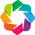

:Overlay
   .Scatter.I :Scatter   [actual_swe]   (pred_swe)
   .Curve.I   :Curve   [x]   (y)

In [71]:

hv.extension('bokeh')

# 1. Generate the scatter plot of all test points
scatter_plot = diagnostics_test.hvplot.scatter(
    x='actual_swe',
    y='pred_swe',
    alpha=0.2,
    color='teal',
    xlabel='Observed SNOTEL SWE (mm)',
    ylabel='Predicted RF SWE (mm)',
    title='Missouri Headwaters: Observed vs. Predicted SWE',
    frame_width=500,
    frame_height=500
)

# 2. Create a perfect 1:1 reference line
max_val = max(diagnostics_test['actual_swe'].max(), diagnostics_test['pred_swe'].max())

one_to_one_line = hv.Curve(([0, max_val], [0, max_val])).opts(
    color='red', 
    line_dash='dashed', 
    line_width=2
)

# Overlay them
observed_vs_predicted = scatter_plot * one_to_one_line
observed_vs_predicted

In [72]:
diagnostics_test['date'] = stations_test['date']
diagnostics_test = diagnostics_test.set_index('date')

# Assuming your X_test index is a datetime object, or you have a 'date' column
# Let's aggregate by date to see the watershed's seasonal trajectory
temporal_profile = diagnostics_test.groupby(diagnostics_test.index).mean()

hydrograph = temporal_profile.hvplot.line(
    y=['actual_swe', 'pred_swe'],
    value_label='SWE (mm)',
    legend='top_left',
    color=['black', 'blue'],
    line_width=[2, 2],
    title='Watershed-Average SWE Hydrograph (Holdout Period)',
    frame_width=800,
    frame_height=400
)

hydrograph

:NdOverlay   [Variable]
   :Curve   [date]   (SWE (mm))

## Step 5: Hyperparameter Tuning

##### Round 1 of Hyperparameter Tuning

This round was completed before the addition of two more features to the dataset, so it's a decent place to start from, but more tuning is needed.

In [ ]:
# reset model
rf_model = RandomForestRegressor(random_state=42)

# define a parameter distribution
params = {
    # set the number of possible trees
    'n_estimators': [100, 200, 300, 400, 500],
    # how many features each tree can consider
    'max_features': ['sqrt', 'log2'],
    # how deep each tree can go
    'max_depth': [10, 20, 30, 40, 50],
}

# use a time series cross validation
# otherwise, RandomizedSearch will use a cross validation that is incompatible with climate data
tscv = TimeSeriesSplit(n_splits=5)

# set up a randomized search
rf_random = RandomizedSearchCV(
    # use the rf model
    estimator = rf_model,
    # search through the dictionary
    param_distributions = params,
    # number of param iterations to try
    n_iter = 25,
    # use the time series cross validation
    cv = tscv,
    # optimize for RMSE error, as that was worse than R2
    scoring='neg_root_mean_squared_error',
    # enable parallelization
    n_jobs = -1
)

# complete the randomized search
rf_random.fit(x_train, y_train)

# extract best parameters
print("First round of hyperparameter tuning results:", rf_random.best_params_)
r1_best_params = rf_random.best_estimator_
r1_best_params

c:\Users\raini\miniconda3\envs\earth-analytics-python\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


First round of hyperparameter tuning results: {'n_estimators': 500, 'max_features': 'log2', 'max_depth': 30}


,n_estimators,500
,criterion,'squared_error'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


##### Round 2 of Hyperparameter Tuning

This round will narrow the search, guided by the first round but not fully believing it. The first round of hyperparameter tuning results were: {'n_estimators': 500, 'max_features': 'log2', 'max_depth': 30}

Following this, the second round will use n_features: [400, 500, 600], the same max features, and max_depth: [20, 30, 40]

In [56]:
# set new params
params = {
    'n_estimators': [400, 500, 600],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [20, 30, 40],
}

# set up the randomized search
rf_random_2 = RandomizedSearchCV(
    # use the rf model
    estimator = rf_model,
    # search through the dictionary
    param_distributions = params,
    # number of param iterations to try
    n_iter = 18,
    # use the time series cross validation
    cv = tscv,
    # optimize for RMSE error, as that was worse than R2
    scoring='neg_root_mean_squared_error',
    # enable parallelization
    n_jobs = -1
)

# complete the randomized search
rf_random_2.fit(x_train, y_train)

c:\Users\raini\miniconda3\envs\earth-analytics-python\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [20, 30, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [400, 500, ...]}"
,n_iter,18
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [58]:
# extract best parameters
print("Seond round of hyperparameter tuning results:", rf_random_2.best_params_)
r2_best_params = rf_random_2.best_estimator_
r2_best_params

Seond round of hyperparameter tuning results: {'n_estimators': 400, 'max_features': 'sqrt', 'max_depth': 40}


,n_estimators,400
,criterion,'squared_error'
,max_depth,40
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


These results are a bit interesting. The max_features changed from log2 to sqrt, indicating that the model is benefiting from the additional features added. Further, the n_estimators actually went down to 400 from 500. Finally, the max_depth went up to 40, indicating that the model is benefiting from the additional features and building additional complexity.

##### Round 3 of Hyperparameter Tuning

Scores from the second round of tuning aren't markedly better than before. This round will keep the n_estimators and the max_depth, but try a Grid Search with a greater number of features.

In [73]:
# reset model
rf_grid = RandomForestRegressor(random_state=42, n_jobs=-1)

# set up params again
params_grid = {
    'n_estimators': [400],
    'max_depth': [40],
    # with 15 features, 'sqrt' will include 3 features (20%) of the features from the dataset in each tree
    # this search will test how including half and three quarters of the features performs
    'max_features': ['sqrt', 0.5, 0.75]
}

# set up Grid Search
grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=params_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# perform grid search
grid_search.fit(x_train, y_train)

# Print results
print("Best Parameters from Grid Search:", grid_search.best_params_)
gs_best_params = grid_search.best_estimator_
gs_best_params

Fitting 5 folds for each of 3 candidates, totalling 15 fits


c:\Users\raini\miniconda3\envs\earth-analytics-python\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best Parameters from Grid Search: {'max_depth': 40, 'max_features': 'sqrt', 'n_estimators': 400}


,n_estimators,400
,criterion,'squared_error'
,max_depth,40
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


These results confirm that the previous set of parameters were the best - max_features is still best left as sqrt.

## Step 6: Run RF Model with final parameters

In [59]:
# run model with updated parameters

rf_final = RandomForestRegressor(
    n_estimators=400,
    max_features='sqrt',
    max_depth=40,
    random_state=42,
    n_jobs=-1
)

In [60]:
# fit model
rf_final.fit(x_train, y_train)

# predict
rf_preds_final = rf_final.predict(x_test)

c:\Users\raini\miniconda3\envs\earth-analytics-python\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [62]:
# Evaluate model performance

# Calculate some error statistics
rf_rmse_final = root_mean_squared_error(y_test, rf_preds_final)
rf_r2_final = r2_score(y_test, rf_preds_final)

# check error statistics
print(f"RF Test RMSE: {rf_rmse_final} mm")
print(f"RF Test R^2: {rf_r2_final}")

RF Test RMSE: 117.09032252833718 mm
RF Test R^2: 0.7318620037388166


Add some reflection here.

## Step 7: Save ML model and Apply to PRISM dataset